In [33]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv('../datasets/AmesHousing.csv')

In [35]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [36]:
(df.isnull().mean()*100)[df.isnull().sum()>0]
#This is called boolean masking i.e. (result)[mask]

Lot Frontage      16.723549
Alley             93.242321
Mas Vnr Type      60.580205
Mas Vnr Area       0.784983
Bsmt Qual          2.730375
Bsmt Cond          2.730375
Bsmt Exposure      2.832765
BsmtFin Type 1     2.730375
BsmtFin SF 1       0.034130
BsmtFin Type 2     2.764505
BsmtFin SF 2       0.034130
Bsmt Unf SF        0.034130
Total Bsmt SF      0.034130
Electrical         0.034130
Bsmt Full Bath     0.068259
Bsmt Half Bath     0.068259
Fireplace Qu      48.532423
Garage Type        5.358362
Garage Yr Blt      5.426621
Garage Finish      5.426621
Garage Cars        0.034130
Garage Area        0.034130
Garage Qual        5.426621
Garage Cond        5.426621
Pool QC           99.556314
Fence             80.477816
Misc Feature      96.382253
dtype: float64

In [37]:
df.dtypes[df.isnull().sum()>0]

Lot Frontage      float64
Alley              object
Mas Vnr Type       object
Mas Vnr Area      float64
Bsmt Qual          object
Bsmt Cond          object
Bsmt Exposure      object
BsmtFin Type 1     object
BsmtFin SF 1      float64
BsmtFin Type 2     object
BsmtFin SF 2      float64
Bsmt Unf SF       float64
Total Bsmt SF     float64
Electrical         object
Bsmt Full Bath    float64
Bsmt Half Bath    float64
Fireplace Qu       object
Garage Type        object
Garage Yr Blt     float64
Garage Finish      object
Garage Cars       float64
Garage Area       float64
Garage Qual        object
Garage Cond        object
Pool QC            object
Fence              object
Misc Feature       object
dtype: object

In [38]:
df = pd.read_csv('../datasets/AmesHousing.csv', usecols=['Garage Yr Blt','SalePrice','Mas Vnr Area'])

In [39]:
df.sample(5)

,Mas Vnr Area,Garage Yr Blt,SalePrice
2777,0.0,1999.0,217000
259,0.0,1977.0,150000
1988,0.0,1935.0,100000
1625,0.0,1999.0,204000
1959,0.0,1950.0,119000


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Mas Vnr Area   2907 non-null   float64
 1   Garage Yr Blt  2771 non-null   float64
 2   SalePrice      2930 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 68.8 KB


In [41]:
df.isnull().sum()

Mas Vnr Area      23
Garage Yr Blt    159
SalePrice          0
dtype: int64

In [42]:
df.isnull().mean()*100

Mas Vnr Area     0.784983
Garage Yr Blt    5.426621
SalePrice        0.000000
dtype: float64

In [43]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

In [44]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [45]:
X_train['Garage_Yr_Blt_imputed'] = X_train['Garage Yr Blt']
X_test['Garage_Yr_Blt_imputed'] = X_test['Garage Yr Blt']

In [46]:
X_train['Garage_Yr_Blt_imputed'][X_train['Garage_Yr_Blt_imputed'].isnull()] = X_train['Garage Yr Blt'].dropna().sample(X_train['Garage Yr Blt'].isnull().sum()).values
# The LHS is boolean masking. The RHS, count the number of null values, sample that many values from X_train's garage yr blt col, drop the null values from the X_train's garage yr blt col. Then fill it in the imputed values column.

/var/folders/4r/r54s3_591ybgs6zwhwsjs1z00000gn/T/ipykernel_69502/1304882752.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Garage_Yr_Blt_imputed'][X_train['Garage_Yr_Blt_imputed'].isnull()] = X_train['Garage Yr Blt'].dropna().s

In [47]:
X_test['Garage_Yr_Blt_imputed'][X_test['Garage_Yr_Blt_imputed'].isnull()] = X_test['Garage Yr Blt'].dropna().sample(X_test['Garage Yr Blt'].isnull().sum()).values

/var/folders/4r/r54s3_591ybgs6zwhwsjs1z00000gn/T/ipykernel_69502/4049545173.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_test['Garage_Yr_Blt_imputed'][X_test['Garage_Yr_Blt_imputed'].isnull()] = X_test['Garage Yr Blt'].dropna().samp

In [48]:
X_train.sample(5)

,Mas Vnr Area,Garage Yr Blt,Garage_Yr_Blt_imputed
466,0.0,2005.0,2005.0
1368,0.0,1997.0,1997.0
2067,0.0,1940.0,1940.0
1971,0.0,1962.0,1962.0
1890,202.0,1966.0,1966.0


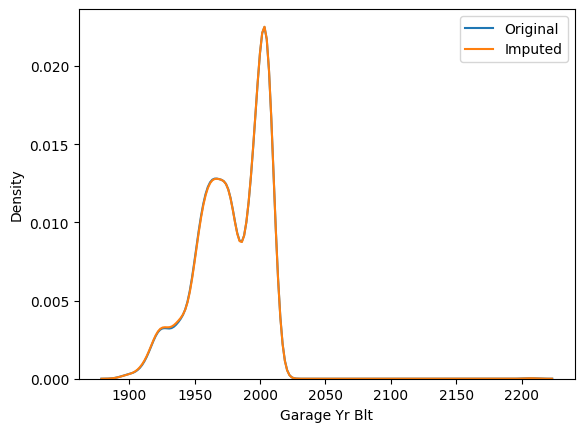

In [49]:
sns.kdeplot(X_train['Garage Yr Blt'], label='Original')
sns.kdeplot(X_train['Garage_Yr_Blt_imputed'], label='Imputed')
plt.legend()
plt.show()

In [50]:
print('Original variable variance: ', X_train['Garage Yr Blt'].var())
print('Variance after random imputation: ', X_train['Garage_Yr_Blt_imputed'].var())
#Not much change, which is good

Original variable variance:  659.6443851633683
Variance after random imputation:  663.1558968039284


In [51]:
X_train[['Mas Vnr Area','Garage Yr Blt', 'Garage_Yr_Blt_imputed']].cov()

,Mas Vnr Area,Garage Yr Blt,Garage_Yr_Blt_imputed
Mas Vnr Area,33141.689453,1193.782601,1134.438207
Garage Yr Blt,1193.782601,659.644385,659.644385
Garage_Yr_Blt_imputed,1134.438207,659.644385,663.155897


<Axes: >

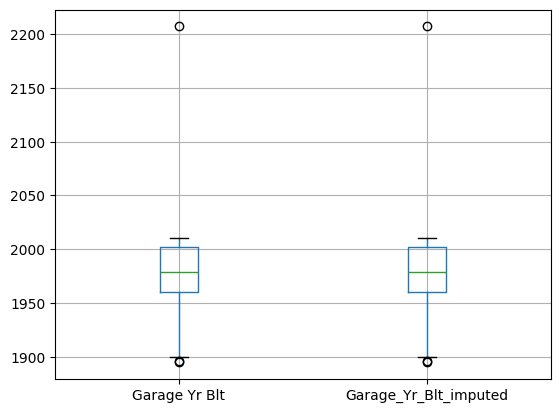

In [52]:
X_train[['Garage Yr Blt','Garage_Yr_Blt_imputed']].boxplot()
#Not much difference in the boxplots and the outliners

In [54]:
observation = X_train.iloc[0]

In [55]:
sampled_value = X_train['Garage Yr Blt'].dropna().sample(1, random_state=int(observation['Mas Vnr Area']))

In [56]:
sampled_value

2633    1962.0
Name: Garage Yr Blt, dtype: float64